# 10m Wind Speed Analysis: Historical vs Control vs Projection

This notebook analyses the 10 metre wind speed over Scandinavia (including Finland) for **8 August 2023** (hourly data) across three storyline experiments and using 3 ensemble members:

| Label | Experiment key | Description |
|-------|---------------|-------------|
| Historical | `hist` | Past/historical climate |
| Control | `cont` | Present-day climate |
| Projection | `Tplus2.0K` | +2 K warmer storyline |

**What we do:**
1. Download all ensemble members for all 24 hours of 8 Aug 2023 for each experiment
2. Compute ensemble-mean
3. Plot spatial wind speed *differences* between the experiments at 12 UTC

**References:**
- [Climate DT user guide](https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide)
- [ECMWF parameter DB – param 207](https://codes.ecmwf.int/grib/param-db/)
- John et al. 2026, *Global Kilometer-Scale Climate Storylines Using Spectral Nudging*

In [15]:
import earthkit.data as ekd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import pandas as pd

## Configuration

**Tasks**:  Create a request for the required data. Use the variables below so you can easily modify the request. Regrid the data serverside to 0.1 degree. 
- `REALIZATIONS`: list of ensemble member numbers to request.
- `RESOLUTION`: `'standard'` (H128, ~50 km) is faster for testing; switch to `'high'` (H512, ~10 km) for production.

In [ ]:
EXPERIMENTS = ['hist', 'cont', 'Tplus2.0K']

REALIZATIONS = ['1', '2', '3']    # ensemble members to attempt
DATE         = '20230808'         # 8 August 2023
PARAM        = '207'              # 10 metre wind speed
RESOLUTION   = 'high'             # 'standard' (~50 km) or 'high' (~10 km)
TIME         = '1200'             # single time step

# Server-side regridding target resolution
GRID = '0.1/0.1'

# Scandinavia + Finland area: N/W/S/E
AREA    = '72/4/54/32'
ADDRESS = 'polytope.mn5.apps.dte.destination-earth.eu'

## 1. Data Request and Download

We use **server-side regridding**: by adding `'grid'`, `'interpolation'`, and `'area'` keys to the request, Polytope reprojects the native HEALPix data to a regular lat/lon grid before sending it back. This means:
- The response is a standard GRIB file — `data.ls()` works normally.
- `to_xarray()` returns a dataset with proper `latitude` / `longitude` / `valid_time` dimensions instead of the unstructured `points` / `datetimes` dimensions from a bounding-box CovJSON response.
- All experiments land on **exactly the same grid**, so differences are computed by plain xarray subtraction — no interpolation step needed.

We loop over each experiment and ensemble member; failed realizations are caught and skipped.

In [17]:
def build_request(experiment, realization):
    """Return a Polytope request dict for one experiment / realization."""
    return {
        'activity'      : 'story-nudging',
        'class'         : 'd1',
        'dataset'       : 'climate-dt',
        'experiment'    : experiment,
        'expver'        : '0001',
        'model'         : 'ifs-fesom',
        'generation'    : '2',
        'realization'   : realization,
        'resolution'    : RESOLUTION,
        'date'          : DATE,
        'time'          : TIME,
        'stream'        : 'clte',
        'type'          : 'fc',
        'levtype'       : 'sfc',
        'param'         : PARAM,
        # Server-side regridding — returns regular lat/lon GRIB instead of HEALPix CovJSON
        'grid'          : GRID,
        'interpolation' : 'grid-box-average',
        'area'          : AREA,   # N/W/S/E  (replaces the bounding-box 'feature' key)
    }

In the next step we loop over all of the data requests and combine them into one dataset. An alternative is to make different datasets for each experiment type.

In [23]:
datasets = {}  # {exp: xr.Dataset with dim 'realization' prepended}

for exp in EXPERIMENTS:
    print(f'\n=== Experiment: {exp} ===')
    realization_datasets = []

    for r in REALIZATIONS:
        print(f'  Requesting realization {r} ...', end=' ', flush=True)
        
        data = ekd.from_source(
                'polytope', 'destination-earth',
                build_request(exp, r),
                stream=False,
                address=ADDRESS,
            )
        ds = data.to_xarray()

        # GRIB xarray may carry trivial 'number' or 'step' dimensions — drop them
        squeeze_dims = [d for d in ('number', 'step') if d in ds.dims and ds.dims[d] == 1]
        if squeeze_dims:
            ds = ds.squeeze(squeeze_dims, drop=True)

        # Tag with the realization number so we can concatenate cleanly
        ds = ds.expand_dims({'realization': [int(r)]})
        realization_datasets.append(ds)
        print('OK')

    datasets[exp] = xr.concat(realization_datasets, dim='realization')
    print(f'  Dataset shape: {dict(datasets[exp].dims)}')

print('\nDownload complete.')


=== Experiment: hist ===
  Requesting realization 1 ... 

2026-06-09 19:55:55 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-09 19:55:55 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 72/4/54/32\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20230808'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.1/0.1\n'
            'interpolation: grid-box-average\n'
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '207'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 19:55:55 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-09 19:55:56 - INFO - Request accepted. Please poll ./a21dcc8f-8b84-47af-afe7-003553700f82 for status
2026-06-09 19:55:56 - INFO - Polytope user key found in session cache for user

OK
  Requesting realization 2 ... 

2026-06-09 19:56:00 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-09 19:56:00 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 72/4/54/32\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20230808'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.1/0.1\n'
            'interpolation: grid-box-average\n'
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '207'\n"
            "realization: '2'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 19:56:00 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-09 19:56:00 - INFO - Request accepted. Please poll ./64e83ecd-bad6-4b1e-a7f1-af180193a022 for status
2026-06-09 19:56:00 - INFO - Polytope user key found in session cache for user

OK
  Requesting realization 3 ... 

...

OK
  Requesting realization 2 ... 

2026-06-09 19:56:29 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-09 19:56:29 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 72/4/54/32\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20230808'\n"
            'experiment: Tplus2.0K\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.1/0.1\n'
            'interpolation: grid-box-average\n'
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '207'\n"
            "realization: '2'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 19:56:29 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-09 19:56:29 - INFO - Request accepted. Please poll ./12722b90-4588-4add-87b6-ea51f58bb6e2 for status
2026-06-09 19:56:29 - INFO - Polytope user key found in session cache for

OK
  Requesting realization 3 ... 

2026-06-09 19:56:34 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-09 19:56:34 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 72/4/54/32\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20230808'\n"
            'experiment: Tplus2.0K\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.1/0.1\n'
            'interpolation: grid-box-average\n'
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '207'\n"
            "realization: '3'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-09 19:56:34 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-09 19:56:35 - INFO - Request accepted. Please poll ./d452c5e1-f06f-4392-9061-9bd3461f8413 for status
2026-06-09 19:56:35 - INFO - Polytope user key found in session cache for

OK
  Dataset shape: {'realization': 3, 'latitude': 181, 'longitude': 281}

Download complete.


## 2. Data Inspection

Let's check the structure of the downloaded data and identify the wind speed variable name.

In [19]:
# Show the first experiment's dataset as a representative example
first_exp = EXPERIMENTS[0]
print(f'Structure of {first_exp} dataset:')
print(datasets[first_exp])

print('\nData variables available:')
for exp in datasets:
    print(f'  {exp}: {list(datasets[exp].data_vars)}')

Structure of hist dataset:
<xarray.Dataset> Size: 1MB
Dimensions:      (realization: 3, latitude: 181, longitude: 281)
Coordinates:
  * realization  (realization) int64 24B 1 2 3
  * latitude     (latitude) float64 1kB 72.0 71.9 71.8 71.7 ... 54.2 54.1 54.0
  * longitude    (longitude) float64 2kB 4.0 4.1 4.2 4.3 ... 31.7 31.8 31.9 32.0
Data variables:
    10si         (realization, latitude, longitude) float64 1MB 13.61 ... 3.705
Attributes:
    param:        10si
    paramId:      207
    class:        d1
    stream:       clte
    levtype:      sfc
    type:         fc
    expver:       0001
    date:         20230808
    time:         1200
    Conventions:  CF-1.8
    institution:  ECMWF

Data variables available:
  hist: ['10si']
  cont: ['10si']
  Tplus2.0K: ['10si']


## 3. Spatial Wind Speed Differences at 12 UTC

Because we used server-side regridding, every experiment is already on the same 0.1° lat/lon grid. Differences are computed by plain xarray subtraction — no interpolation needed.

We plot three panels:
- **Projection − Historical** (Tplus2.0K − hist)
- **Projection − Control** (Tplus2.0K − cont)
- **Control − Historical** (cont − hist)

In [24]:
# Ensemble-mean spatial field for each experiment (single time step → squeeze time dim)
# Result is a DataArray with dims (latitude, longitude)
spatial = {}

for exp in datasets:
    wind = datasets[exp]['10si']                 # (realization, <time>, latitude, longitude)
    spatial[exp] = wind.mean(dim='realization').squeeze()  # drops the single time dim

# Pairwise differences — direct xarray arithmetic, same grid guaranteed
diffs = {
    'Projection − Historical\n(Tplus2.0K − hist)': spatial['Tplus2.0K'] - spatial['hist'],
    'Projection − Control\n(Tplus2.0K − cont)'  : spatial['Tplus2.0K'] - spatial['cont'],
    'Control − Historical\n(cont − hist)'        : spatial['cont']      - spatial['hist'],
}

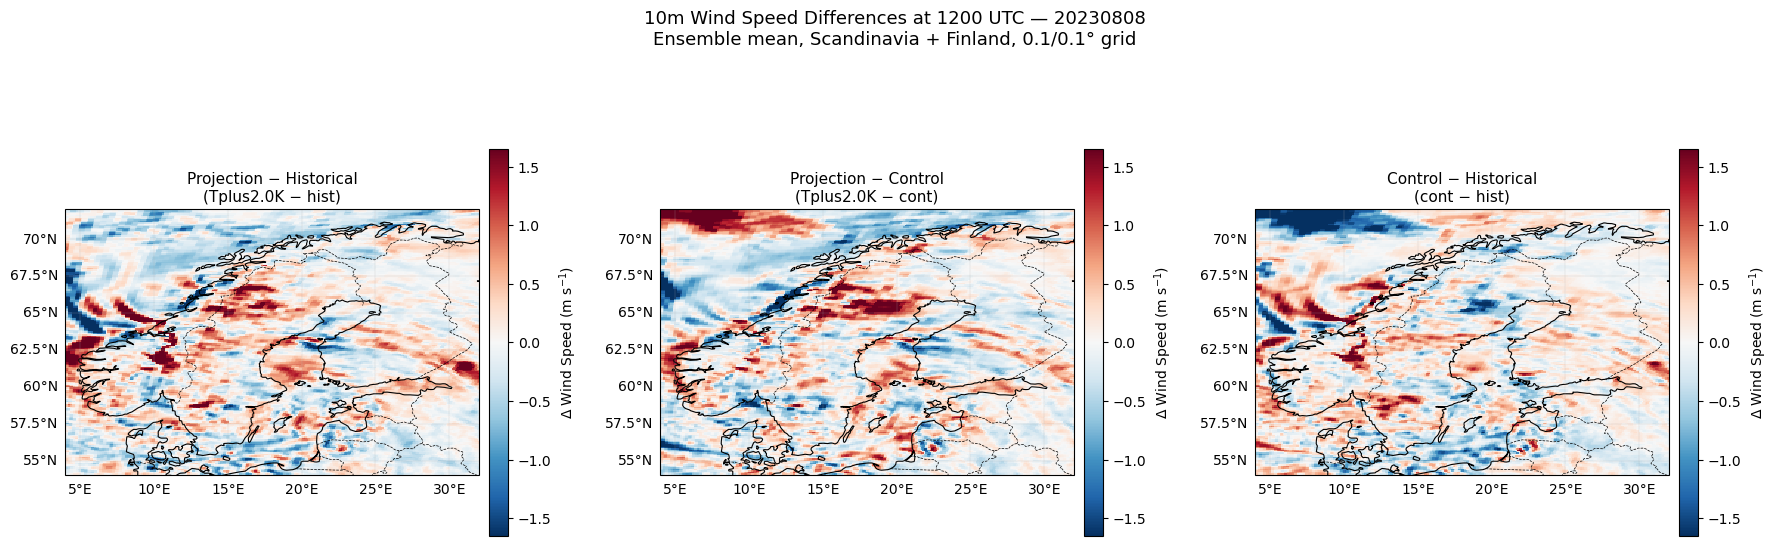

In [25]:
# Symmetric colour scale: use 98th-percentile absolute value across all three differences
all_vals = np.concatenate([d.values[~np.isnan(d.values)].ravel() for d in diffs.values()])
vmax = float(np.nanpercentile(np.abs(all_vals), 98))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# lat/lon come straight from the xarray coordinates — no linspace needed
lat_out = datasets[EXPERIMENTS[0]].latitude.values
lon_out = datasets[EXPERIMENTS[0]].longitude.values

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

for ax, (title, diff) in zip(axes, diffs.items()):
    ax.set_extent([4, 32, 54, 72], crs=ccrs.PlateCarree())

    pcm = ax.pcolormesh(
        lon_out, lat_out, diff.values,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        norm=norm,
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels   = False
    gl.right_labels = False

    plt.colorbar(pcm, ax=ax, label='Δ Wind Speed (m s$^{-1}$)', shrink=0.75, pad=0.02)
    ax.set_title(title, fontsize=11)

fig.suptitle(
    f'10m Wind Speed Differences at {TIME} UTC — {DATE}\n'
    f'Ensemble mean, Scandinavia + Finland, {GRID}° grid',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Summary

| Panel | What it shows |
|-------|---------------|
| **Tplus2.0K − hist** | Difference between historical forcings and the +2 K storyline warming |
| **Tplus2.0K − cont** | Wind response in the +2 K future vs the 1950s |
| **cont − hist** | Difference between past and present |

Red = stronger wind in the first experiment; blue = weaker. The symmetric diverging scale is set to the 98th-percentile absolute difference to avoid outlier saturation.